# Document Scanner Pipeline — DDI-100 Dataset
### Edge Detection · Perspective Transformation · Image Enhancement · Segmentation · OCR · Quantitative Metrics

**Dataset:** [DDI-100](https://www.kaggle.com/datasets/lonelvino/ddi-100) — a large-scale distorted document image dataset with ground-truth masks and text annotations, designed for document analysis research.

**Pipeline stages:**
1. Dataset loading & exploration  
2. Image Enhancement (custom function)  
3. Edge Detection — document boundary detection  
4. Perspective Transformation — distortion correction  
5. Segmentation — text vs. background separation  
6. OCR — optical character recognition  
7. Quantitative Metrics — Accuracy, Precision/Recall, IoU, Matching Accuracy


## 1. Environment Setup

In [2]:
# Install required packages
!pip install pytesseract tqdm -q
# Tesseract is usually pre-installed on Kaggle. If not, uncomment below:
# !apt-get update -qq && apt-get install -y tesseract-ocr tesseract-ocr-eng -qq

import subprocess, sys, os
print("✓ Packages installed")


✓ Packages installed


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, re, json, random, warnings
from pathlib import Path
from tqdm import tqdm
from PIL import Image
import pytesseract
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

warnings.filterwarnings('ignore')
print("✓ All libraries imported")
print(f"  OpenCV  : {cv2.__version__}")
print(f"  Tesseract: {pytesseract.get_tesseract_version()}")


✓ All libraries imported
  OpenCV  : 4.13.0
  Tesseract: 4.1.1


## 2. Download DDI-100 Dataset from Kaggle

**DDI-100** contains:
- ~7000 distorted document images (photographed at various angles)  
- Ground-truth binary masks (text vs. background)  
- Annotation JSON files with bounding boxes and text content  

To use Kaggle API, upload your `kaggle.json` credentials file.


## 2. Dataset Access on Kaggle

On Kaggle, ensure you have added the **DDI-100** dataset to your notebook. 
You can do this by clicking **+ Add Data** in the right sidebar and searching for `lonelvino/ddi-100`.

In [4]:
# ── Update the path to match your specific Kaggle structure ────────────────
DATASET_DIR = "/kaggle/input/datasets/lonelvino/ddi-100/dataset_v1.3/01"

def find_dataset_paths(base_dir):
    """Refined discovery for the specific DDI-100 sub-folder structure."""
    image_paths, mask_paths, annotation_paths = [], [], []

    for root, dirs, files_list in os.walk(base_dir):
        for f in files_list:
            fp = os.path.join(root, f)
            fl = f.lower()
            
            # Map files based on the folder names you listed
            if 'gen_imgs' in root and fl.endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(fp)
            elif 'gen_masks' in root and fl.endswith(('.jpg', '.jpeg', '.png')):
                mask_paths.append(fp)
            elif 'gen_boxes' in root and fl.endswith('.json'):
                annotation_paths.append(fp)

    return sorted(image_paths), sorted(mask_paths), sorted(annotation_paths)

# Re-run the discovery
image_paths, mask_paths, annotation_paths = find_dataset_paths(DATASET_DIR)

print(f"✓ Found {len(image_paths):,} document images")
print(f"✓ Found {len(mask_paths):,} ground-truth masks")

✓ Found 1,620 document images
✓ Found 3,240 ground-truth masks


In [5]:
# ── Locate images, masks, and annotation files ───────────────────────────

def find_dataset_paths(base_dir):
    """Auto-discover image, mask, and annotation paths in DDI-100 structure."""
    image_paths, mask_paths, annotation_paths = [], [], []

    for root, dirs, files_list in os.walk(base_dir):
        for f in files_list:
            fp = os.path.join(root, f)
            fl = f.lower()
            if fl.endswith(('.jpg', '.jpeg', '.png')) and 'mask' not in root.lower():
                image_paths.append(fp)
            elif fl.endswith(('.jpg', '.jpeg', '.png')) and 'mask' in root.lower():
                mask_paths.append(fp)
            elif fl.endswith('.json'):
                annotation_paths.append(fp)

    return sorted(image_paths), sorted(mask_paths), sorted(annotation_paths)

image_paths, mask_paths, annotation_paths = find_dataset_paths(DATASET_DIR)

print(f"✓ Found {len(image_paths):,} document images")
print(f"✓ Found {len(mask_paths):,} ground-truth masks")
print(f"✓ Found {len(annotation_paths):,} annotation files")

# Pair images with masks (by filename stem)
mask_by_stem = {Path(m).stem.replace('_mask','').replace('mask_',''): m
                for m in mask_paths}
paired = [(img, mask_by_stem.get(Path(img).stem))
          for img in image_paths
          if mask_by_stem.get(Path(img).stem)]

print(f"\n✓ Paired image+mask samples: {len(paired)}")
print(f"  Sample pair:\n    IMG : {paired[0][0] if paired else 'N/A'}")
print(f"    MASK: {paired[0][1] if paired else 'N/A'}")


✓ Found 1,944 document images
✓ Found 3,348 ground-truth masks
✓ Found 0 annotation files

✓ Paired image+mask samples: 324
  Sample pair:
    IMG : /kaggle/input/datasets/lonelvino/ddi-100/dataset_v1.3/01/orig_backgrounds/0.png
    MASK: /kaggle/input/datasets/lonelvino/ddi-100/dataset_v1.3/01/orig_masks/0.png


## 3. Dataset Exploration

In [7]:
# ── Image statistics ─────────────────────────────────────────────────────
sample_imgs = random.sample(image_paths, min(100, len(image_paths)))
heights, widths, channels_list = [], [], []

for p in sample_imgs:
    img = cv2.imread(p)
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h); widths.append(w)
        channels_list.append(img.shape[2] if img.ndim == 3 else 1)

print("Dataset Image Statistics (sample of 100):")
print(f"  Height — min:{min(heights)}  max:{max(heights)}  mean:{np.mean(heights):.0f}")
print(f"  Width  — min:{min(widths)}  max:{max(widths)}  mean:{np.mean(widths):.0f}")
print(f"  Colour channels: {set(channels_list)}")


Dataset Image Statistics (sample of 100):
  Height — min:2481  max:2729  mean:2687
  Width  — min:1749  max:1923  mean:1893
  Colour channels: {3}


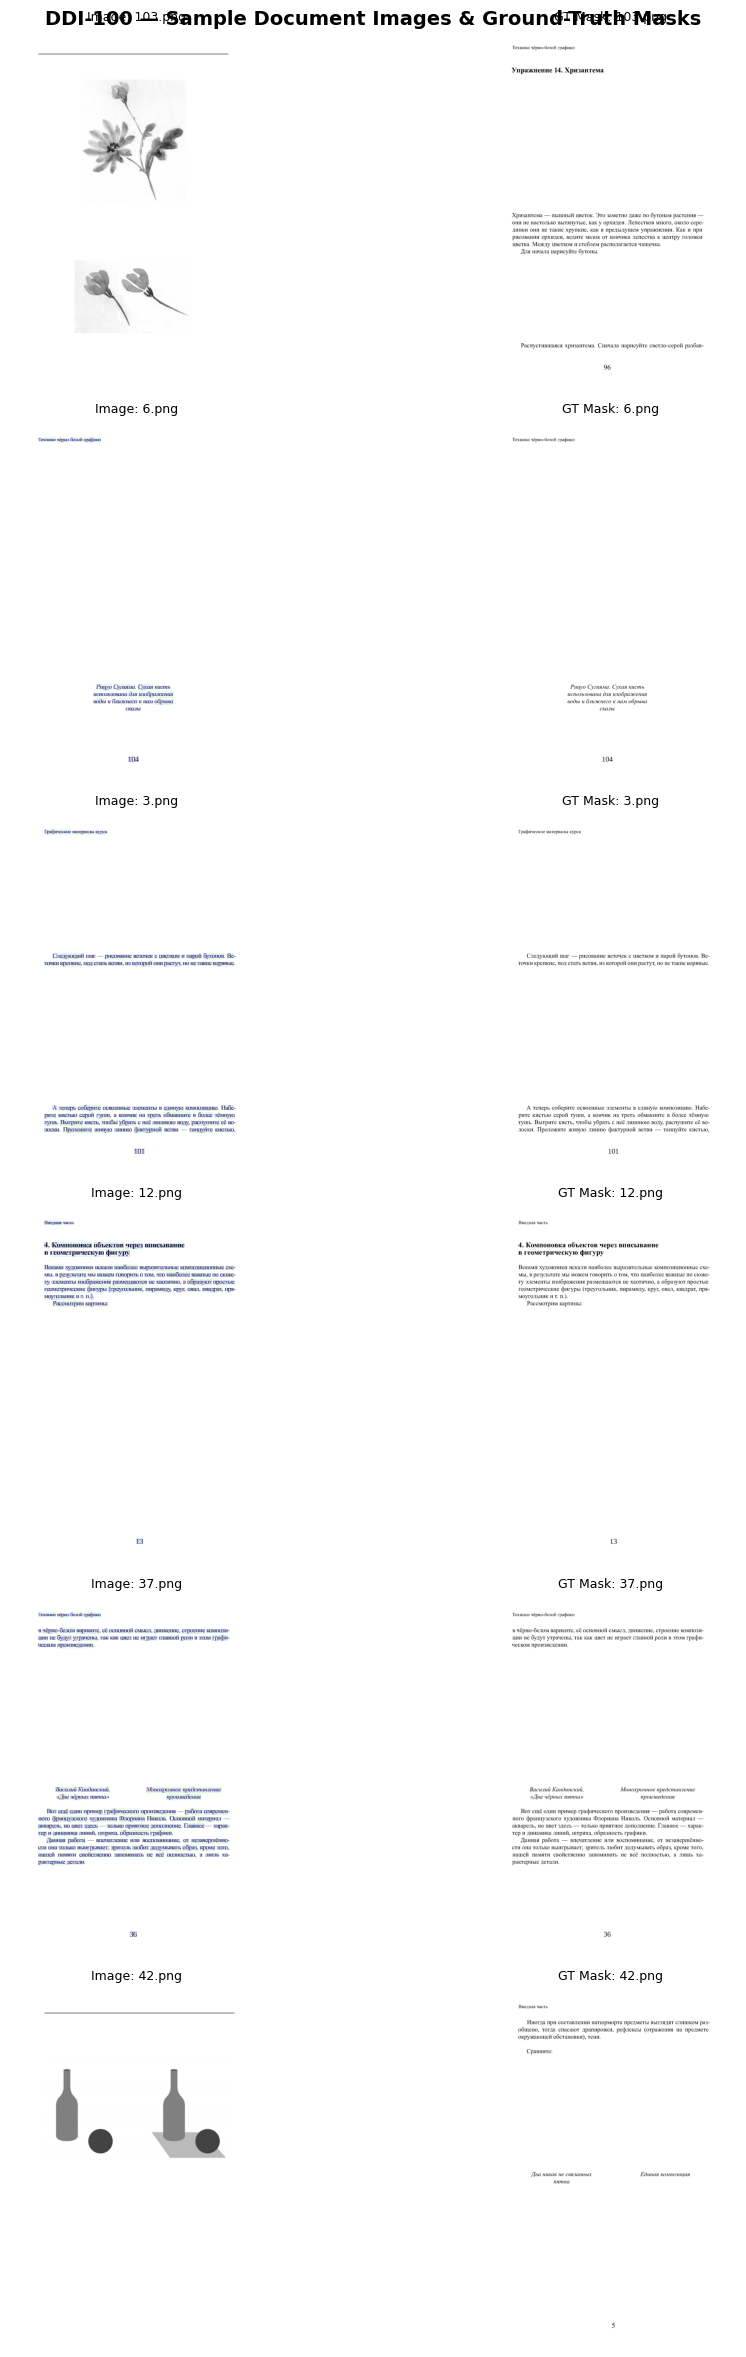

In [8]:
# ── Visualise 6 random samples ───────────────────────────────────────────
sample_show = random.sample(paired if paired else
                            [(p, None) for p in image_paths], min(6, len(image_paths)))

fig, axes = plt.subplots(len(sample_show), 2 if paired else 1,
                         figsize=(12, 4 * len(sample_show)))
fig.suptitle("DDI-100 — Sample Document Images & Ground-Truth Masks",
             fontsize=14, fontweight='bold')

for i, (img_path, mask_path) in enumerate(sample_show):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if paired:
        ax_img  = axes[i, 0] if len(sample_show) > 1 else axes[0]
        ax_mask = axes[i, 1] if len(sample_show) > 1 else axes[1]
        ax_img.imshow(img_rgb)
        ax_img.set_title(f"Image: {Path(img_path).name}", fontsize=9)
        ax_img.axis('off')

        if mask_path:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            ax_mask.imshow(mask, cmap='gray')
            ax_mask.set_title(f"GT Mask: {Path(mask_path).name}", fontsize=9)
        ax_mask.axis('off')
    else:
        ax = axes[i] if len(sample_show) > 1 else axes
        ax.imshow(img_rgb); ax.axis('off')
        ax.set_title(Path(img_path).name, fontsize=9)

plt.tight_layout(); plt.show()


## 4. Image Enhancement

Custom enhancement function with:
- Selective denoising (only for very noisy images, noise_est < 30)
- Conditional upscaling (only if max dimension < 600px)
- CLAHE contrast enhancement (clipLimit=1.8)
- Adaptive Gaussian thresholding
- Automatic polarity correction


In [9]:
import cv2
import numpy as np

def enhance_image(image: np.ndarray) -> np.ndarray:
    """
    Document image enhancement pipeline.
    Returns a clean binary image (uint8, 0/255) ready for OCR & segmentation.
    """
    # 1. Grayscale only
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

    # 2. Light denoise ONLY if needed
    noise_est = cv2.Laplacian(gray, cv2.CV_64F).var()
    if noise_est < 30:  # only very noisy images
        gray = cv2.fastNlMeansDenoising(gray, None, h=6)

    # 3. No resizing unless extremely small (prevents blur)
    h, w = gray.shape
    if max(h, w) < 600:
        gray = cv2.resize(gray, None, fx=1.3, fy=1.3, interpolation=cv2.INTER_CUBIC)

    # 4. Mild contrast only
    clahe = cv2.createCLAHE(clipLimit=1.8, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    # 5. Adaptive threshold directly (no heavy preprocessing chain)
    binary = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        10
    )

    # 6. Polarity fix
    if np.mean(binary) < 127:
        binary = cv2.bitwise_not(binary)

    return binary

print("✓ enhance_image() defined")


✓ enhance_image() defined


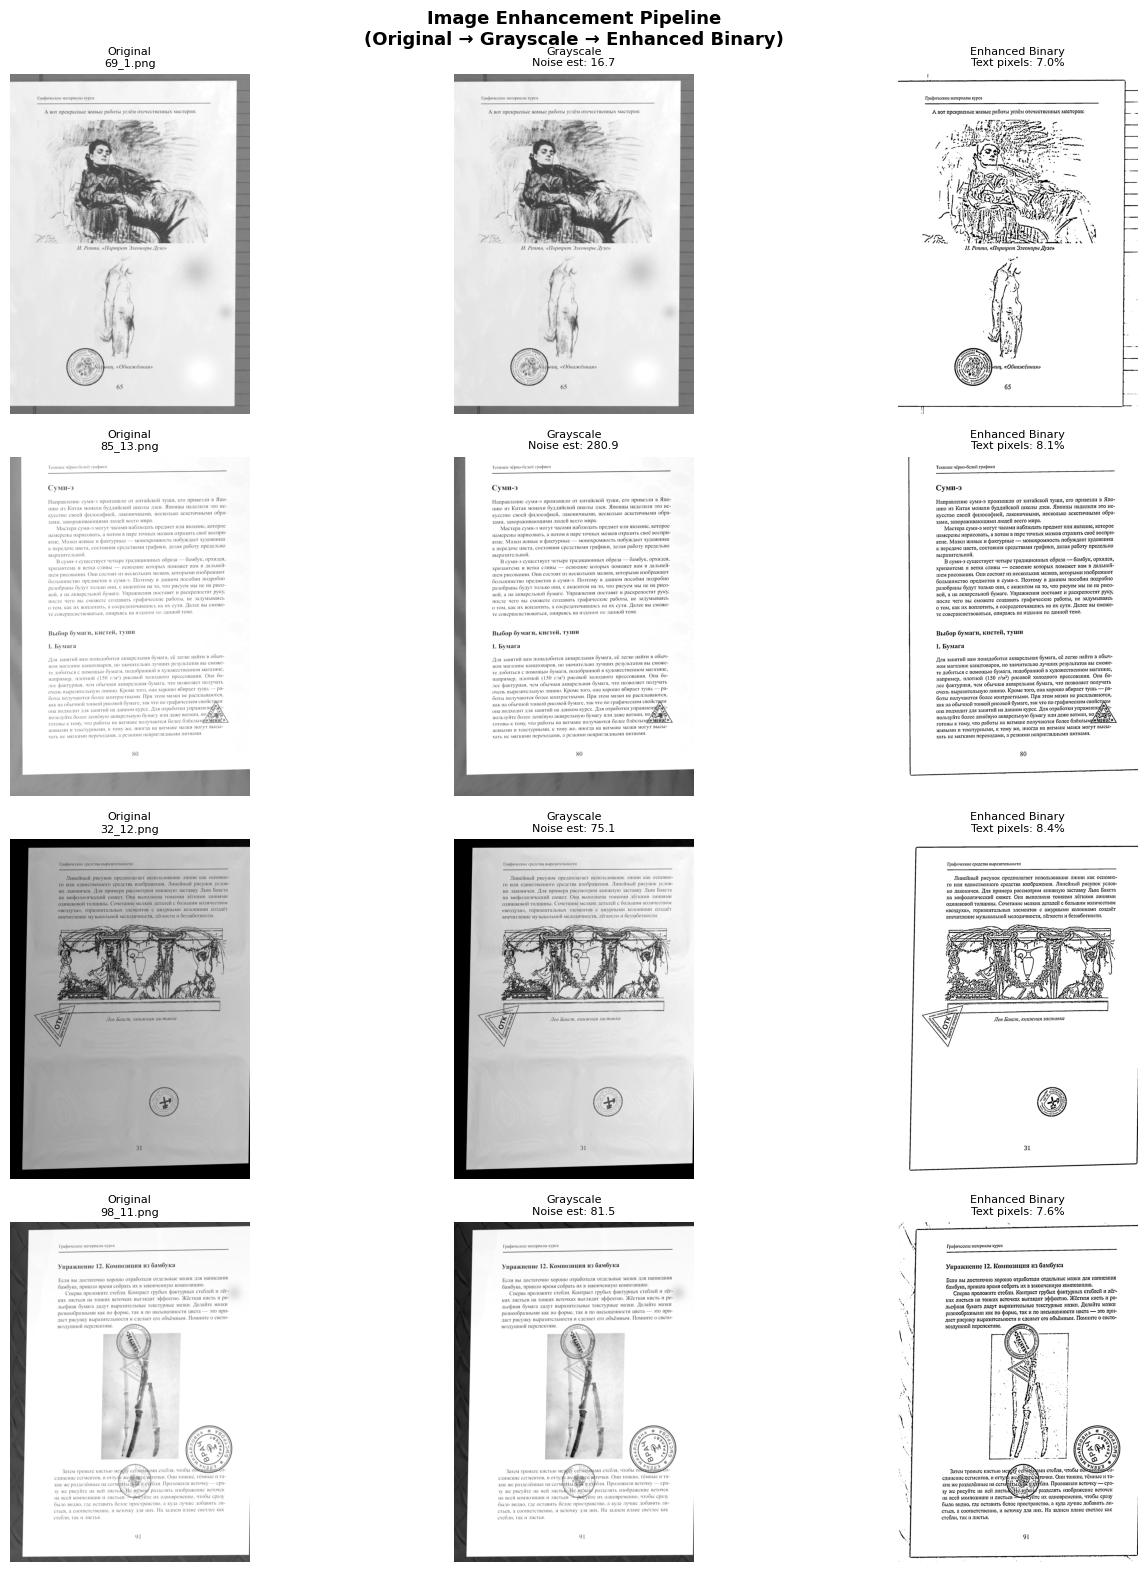


✓ Enhancement visualisation complete


In [10]:
# ── Visualise enhancement on 4 samples ───────────────────────────────────
samples_4 = random.sample(image_paths, min(4, len(image_paths)))

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
fig.suptitle("Image Enhancement Pipeline\n(Original → Grayscale → Enhanced Binary)",
             fontsize=13, fontweight='bold')

for i, img_path in enumerate(samples_4):
    img = cv2.imread(img_path)
    gray_raw = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    enhanced = enhance_image(img)

    axes[i, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"Original\n{Path(img_path).name}", fontsize=8)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(gray_raw, cmap='gray')
    noise_est = cv2.Laplacian(gray_raw, cv2.CV_64F).var()
    axes[i, 1].set_title(f"Grayscale\nNoise est: {noise_est:.1f}", fontsize=8)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(enhanced, cmap='gray')
    text_ratio = (enhanced == 0).sum() / enhanced.size
    axes[i, 2].set_title(f"Enhanced Binary\nText pixels: {text_ratio:.1%}", fontsize=8)
    axes[i, 2].axis('off')

plt.tight_layout(); plt.show()
print("\n✓ Enhancement visualisation complete")


## 5. Edge Detection — Document Boundary Detection

Multi-strategy Canny-based edge detection to locate document corners in photographs.
Applies Gaussian blur before Canny, then uses morphological closing to connect edges.


In [11]:
def detect_edges(img_bgr: np.ndarray) -> dict:
    """
    Detect document boundary edges using multi-scale Canny.
    Returns dict with 'edges', 'blurred', 'otsu_thresh'.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # CLAHE for consistent contrast before edge detection
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    eq    = clahe.apply(gray)

    # Gaussian blur to suppress noise
    blurred = cv2.GaussianBlur(eq, (5, 5), 0)

    # Auto Canny — compute thresholds from Otsu
    otsu_thresh, _ = cv2.threshold(blurred, 0, 255,
                                   cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    edges = cv2.Canny(blurred,
                      threshold1=0.4 * otsu_thresh,
                      threshold2=otsu_thresh)

    # Close gaps in edges
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

    return {
        'edges':        edges_closed,
        'edges_raw':    edges,
        'blurred':      blurred,
        'otsu_thresh':  otsu_thresh
    }

print("✓ detect_edges() defined")


✓ detect_edges() defined


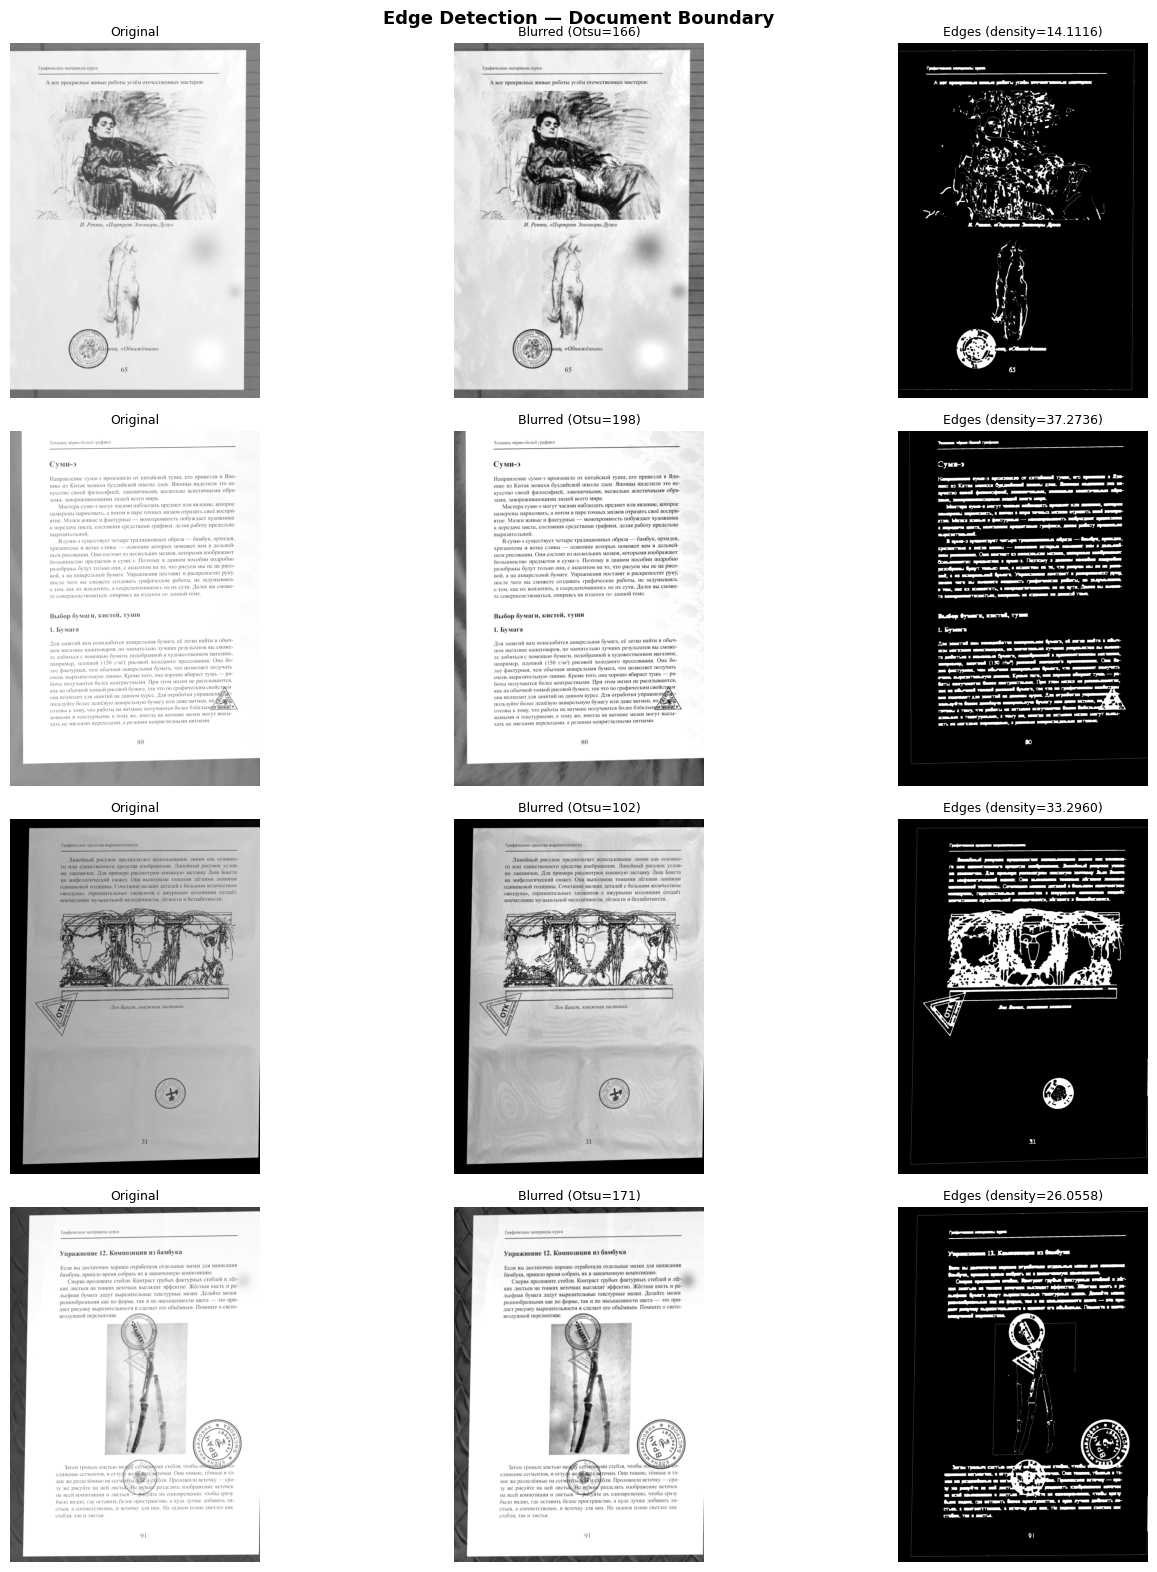

In [12]:
# ── Visualise edge detection on 4 samples ────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
fig.suptitle("Edge Detection — Document Boundary", fontsize=13, fontweight='bold')

for i, img_path in enumerate(samples_4):
    img    = cv2.imread(img_path)
    result = detect_edges(img)

    axes[i, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title("Original", fontsize=9); axes[i, 0].axis('off')

    axes[i, 1].imshow(result['blurred'], cmap='gray')
    axes[i, 1].set_title(f"Blurred (Otsu={result['otsu_thresh']:.0f})", fontsize=9)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(result['edges'], cmap='gray')
    edge_density = result['edges'].sum() / result['edges'].size
    axes[i, 2].set_title(f"Edges (density={edge_density:.4f})", fontsize=9)
    axes[i, 2].axis('off')

plt.tight_layout(); plt.show()


## 6. Perspective Transformation — Distortion Correction

Detects the four corners of the document in the photograph and applies a homographic
warp to produce a flat, front-facing scan.


In [13]:
def order_points(pts: np.ndarray) -> np.ndarray:
    """Sort 4 corner points: top-left, top-right, bottom-right, bottom-left."""
    pts    = pts.reshape(4, 2).astype(np.float32)
    center = pts.mean(axis=0)
    angles = np.arctan2(pts[:, 1] - center[1], pts[:, 0] - center[0])
    pts    = pts[np.argsort(angles)]
    start  = np.argmin(pts.sum(axis=1))
    return np.roll(pts, -start, axis=0).astype("float32")


def four_point_warp(image: np.ndarray, pts: np.ndarray) -> np.ndarray:
    """Apply perspective transform using 4 corner points."""
    rect = order_points(pts)
    tl, tr, br, bl = rect

    w1 = np.linalg.norm(br - bl)
    w2 = np.linalg.norm(tr - tl)
    h1 = np.linalg.norm(tr - br)
    h2 = np.linalg.norm(tl - bl)
    max_w = max(int(w1), int(w2))
    max_h = max(int(h1), int(h2))

    if max_w == 0 or max_h == 0:
        return image

    dst = np.array([
        [0,         0        ],
        [max_w - 1, 0        ],
        [max_w - 1, max_h - 1],
        [0,         max_h - 1],
    ], dtype="float32")

    M      = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (max_w, max_h))

    # Auto-rotate if landscape is detected
    avg_w = (w1 + w2) / 2
    avg_h = (h1 + h2) / 2
    if avg_w > avg_h * 1.2:
        warped = cv2.rotate(warped, cv2.ROTATE_90_CLOCKWISE)

    return warped


def find_document_corners(img_bgr: np.ndarray) -> np.ndarray:
    """
    Detect document quad corners from an image.
    Returns 4-point array or image-border fallback.
    """
    h, w     = img_bgr.shape[:2]
    total_area = h * w
    edge_res  = detect_edges(img_bgr)
    edges     = edge_res['edges']

    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (9, 9), 0)
    _, mask = cv2.threshold(blurred, 0, 255,
                            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Morph-close to fill gaps
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=4)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=2)

    combined = cv2.bitwise_or(edges, mask)
    kernel2  = cv2.getStructuringElement(cv2.MORPH_RECT, (20, 20))
    combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel2, iterations=3)

    cnts, _ = cv2.findContours(combined, cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        pad = 4
        return np.array([[pad,pad],[w-pad,pad],[w-pad,h-pad],[pad,h-pad]], np.float32)

    cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:3]

    for c in cnts:
        if cv2.contourArea(c) < total_area * 0.05:
            continue
        hull = cv2.convexHull(c)
        peri = cv2.arcLength(hull, True)
        for eps in [0.01, 0.02, 0.03, 0.05, 0.08, 0.12]:
            approx = cv2.approxPolyDP(hull, eps * peri, True)
            if len(approx) == 4:
                return order_points(approx.reshape(4, 2))

    # Fallback: bounding rect of largest contour
    c    = max(cnts, key=cv2.contourArea)
    rect = cv2.minAreaRect(c)
    box  = cv2.boxPoints(rect)
    return order_points(box)

print("✓ Perspective transform functions defined")


✓ Perspective transform functions defined


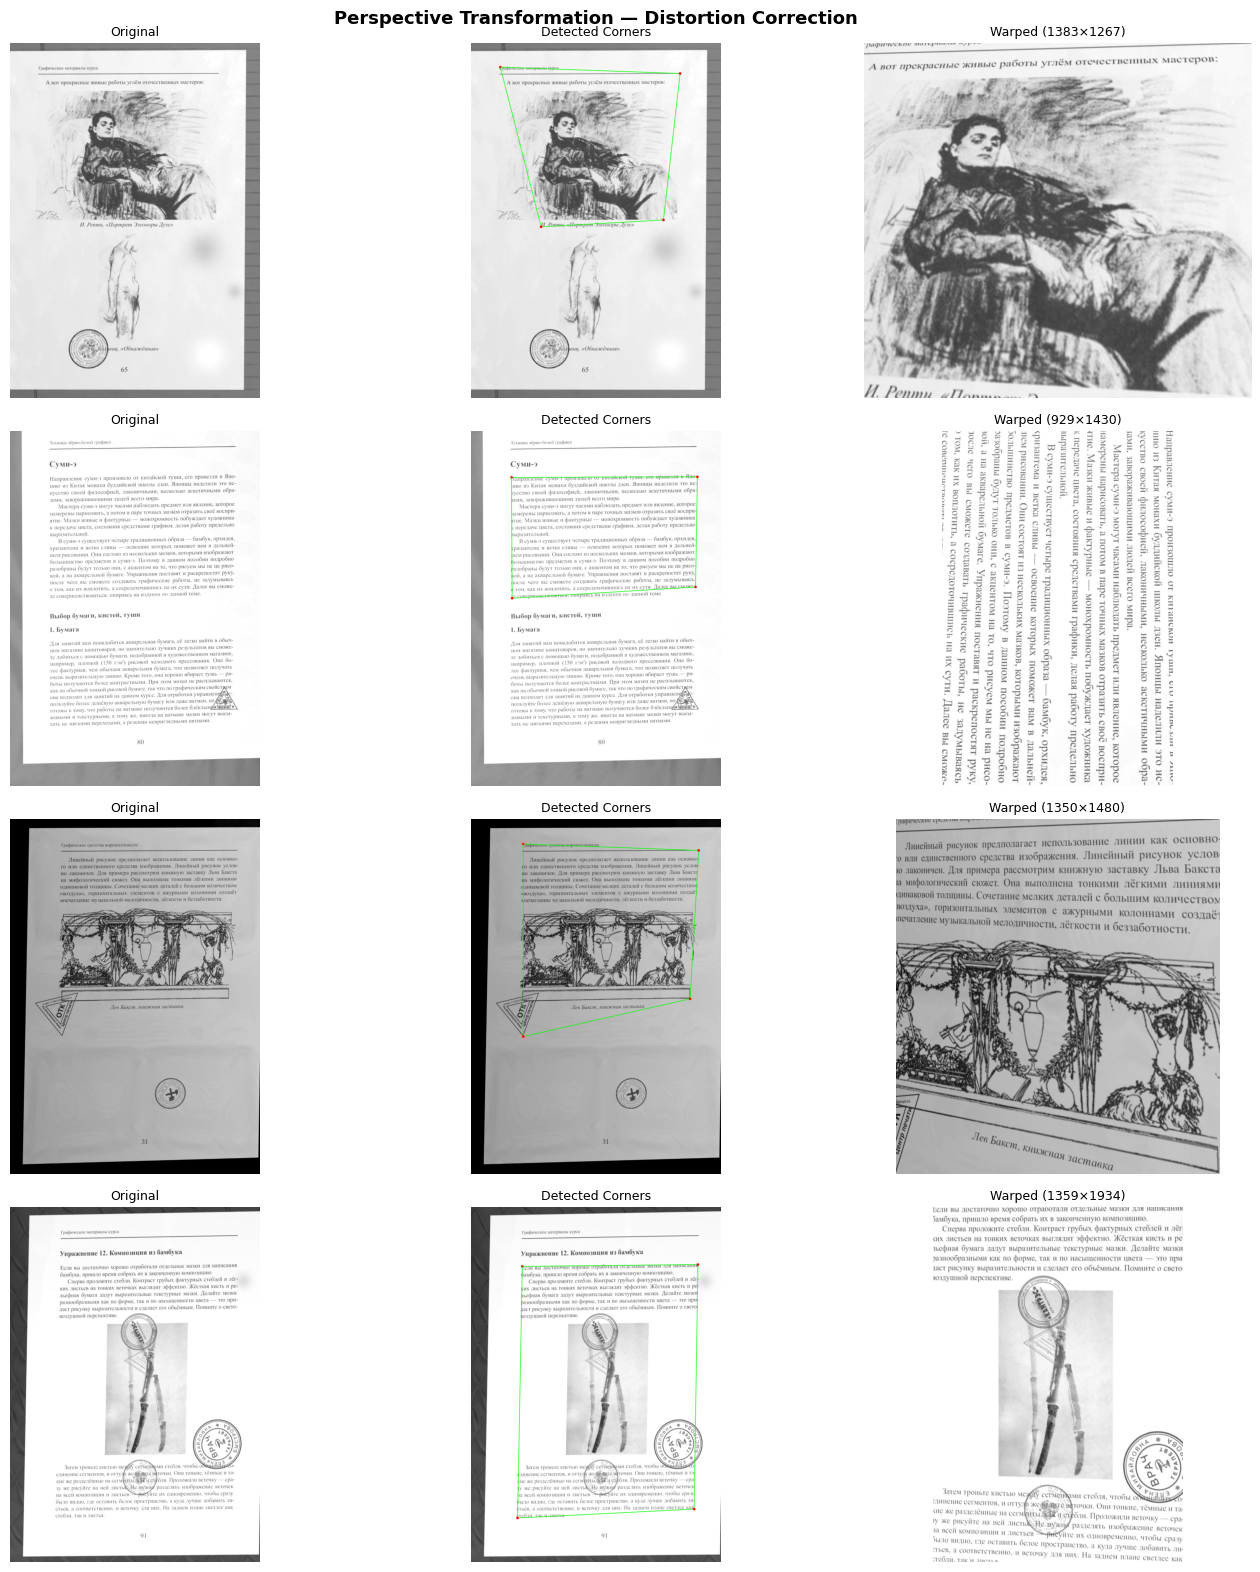

✓ Perspective transformation complete


In [14]:
# ── Visualise perspective correction ─────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
fig.suptitle("Perspective Transformation — Distortion Correction",
             fontsize=13, fontweight='bold')

perspective_results = {}

for i, img_path in enumerate(samples_4):
    img    = cv2.imread(img_path)
    h, w   = img.shape[:2]
    corners = find_document_corners(img)
    warped  = four_point_warp(img, corners)
    perspective_results[img_path] = {
        'corners': corners, 'warped': warped
    }

    # Draw detected corners on copy
    vis = img.copy()
    pts = corners.astype(int)
    for j in range(4):
        cv2.line(vis, tuple(pts[j]), tuple(pts[(j+1)%4]), (0,255,0), 3)
        cv2.circle(vis, tuple(pts[j]), 10, (0,0,255), -1)

    axes[i, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title("Original", fontsize=9); axes[i, 0].axis('off')

    axes[i, 1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title("Detected Corners", fontsize=9); axes[i, 1].axis('off')

    axes[i, 2].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    wh, ww = warped.shape[:2]
    axes[i, 2].set_title(f"Warped ({ww}×{wh})", fontsize=9); axes[i, 2].axis('off')

plt.tight_layout(); plt.show()
print("✓ Perspective transformation complete")


## 7. Segmentation — Text vs. Background

Separates text foreground pixels from background using the `enhance_image()` binary
output.  When ground-truth masks are available, IoU and pixel-level metrics are computed.


In [15]:
def segment_text_background(img_bgr: np.ndarray) -> dict:
    """
    Segment text pixels from background.
    Returns binary mask where 0 = text (foreground), 255 = background.
    """
    # Apply perspective correction first
    corners = find_document_corners(img_bgr)
    warped  = four_point_warp(img_bgr, corners)

    # Enhance to binary
    binary  = enhance_image(warped)

    # Text mask: pixels with value 0 are text
    text_mask = (binary == 0).astype(np.uint8) * 255

    # Character bounding boxes via connected components
    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        text_mask, connectivity=8
    )

    # Filter noise: keep components of reasonable size
    min_area = max(5, (warped.shape[0] * warped.shape[1]) * 0.000005)
    boxes = []
    for label in range(1, n_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if area >= min_area:
            x = stats[label, cv2.CC_STAT_LEFT]
            y = stats[label, cv2.CC_STAT_TOP]
            bw = stats[label, cv2.CC_STAT_WIDTH]
            bh = stats[label, cv2.CC_STAT_HEIGHT]
            boxes.append((x, y, bw, bh))

    return {
        'warped':    warped,
        'binary':    binary,
        'text_mask': text_mask,
        'boxes':     boxes,
        'n_components': n_labels - 1
    }

print("✓ segment_text_background() defined")


✓ segment_text_background() defined


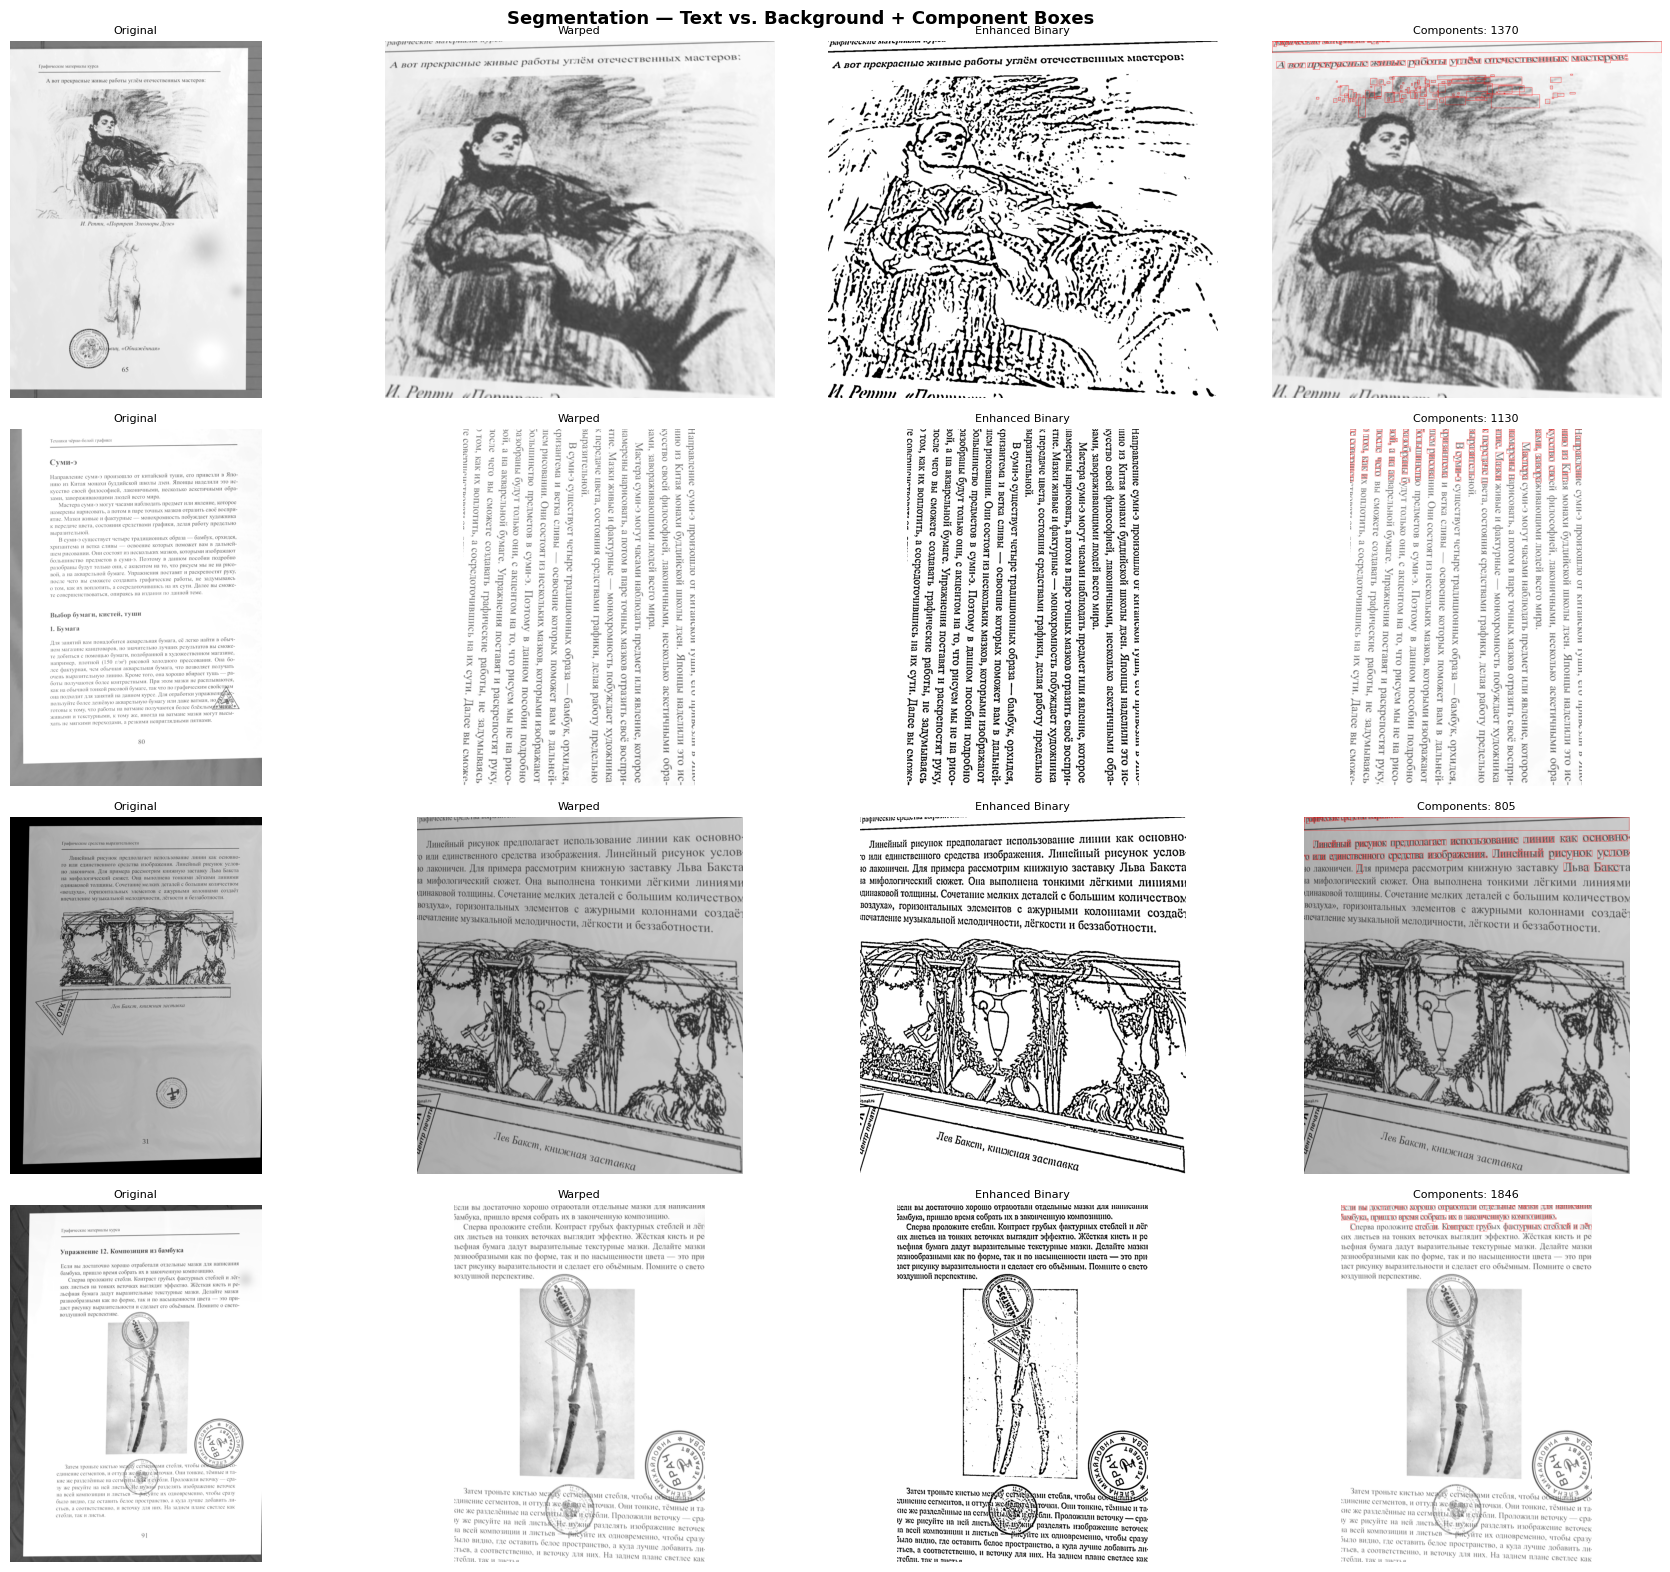

In [16]:
# ── Visualise segmentation ───────────────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
fig.suptitle("Segmentation — Text vs. Background + Component Boxes",
             fontsize=13, fontweight='bold')

seg_results = {}

for i, img_path in enumerate(samples_4):
    img    = cv2.imread(img_path)
    result = segment_text_background(img)
    seg_results[img_path] = result

    # Overlay bounding boxes
    vis = cv2.cvtColor(result['warped'], cv2.COLOR_BGR2RGB).copy()
    for (x, y, bw, bh) in result['boxes'][:200]:
        cv2.rectangle(vis, (x, y), (x+bw, y+bh), (255, 0, 0), 1)

    axes[i, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title("Original", fontsize=8); axes[i, 0].axis('off')

    axes[i, 1].imshow(cv2.cvtColor(result['warped'], cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title("Warped", fontsize=8); axes[i, 1].axis('off')

    axes[i, 2].imshow(result['binary'], cmap='gray')
    axes[i, 2].set_title("Enhanced Binary", fontsize=8); axes[i, 2].axis('off')

    axes[i, 3].imshow(vis)
    axes[i, 3].set_title(f"Components: {result['n_components']}", fontsize=8)
    axes[i, 3].axis('off')

plt.tight_layout(); plt.show()


## 8. OCR — Optical Character Recognition

Applies Tesseract OCR on the perspective-corrected, enhanced binary image.
Includes deskew correction and configurable PSM modes.


In [17]:
import pytesseract
from PIL import Image as PILImage

OCR_CONFIGS = {
    "full_page":    "--oem 3 --psm 3",
    "single_block": "--oem 3 --psm 6",
    "sparse_text":  "--oem 3 --psm 11",
}

def deskew(binary_img: np.ndarray) -> np.ndarray:
    """Correct small rotation angles using minAreaRect."""
    inv    = cv2.bitwise_not(binary_img)
    coords = np.column_stack(np.where(inv > 0))
    if len(coords) < 100:
        return binary_img
    try:
        rect  = cv2.minAreaRect(coords)
        angle = rect[-1]
        if angle < -45:
            angle += 90
    except Exception:
        return binary_img
    if abs(angle) > 10:
        return binary_img
    h, w = binary_img.shape[:2]
    M    = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(binary_img, M, (w, h),
                          flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_CONSTANT,
                          borderValue=255)


def preprocess_for_ocr(binary_img: np.ndarray) -> np.ndarray:
    img = binary_img.copy()
    _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    img = deskew(img)
    h, w = img.shape[:2]
    if max(h, w) < 1000:
        scale = 1000 / max(h, w)
        img = cv2.resize(img, None, fx=scale, fy=scale,
                         interpolation=cv2.INTER_CUBIC)
    img = cv2.medianBlur(img, 3)
    img = cv2.copyMakeBorder(img, 20, 20, 20, 20,
                             cv2.BORDER_CONSTANT, value=255)
    return img


def run_ocr(binary_img: np.ndarray,
            lang: str = 'eng',
            config_key: str = 'full_page') -> str:
    """Run Tesseract OCR on a binary image."""
    ready   = preprocess_for_ocr(binary_img)
    pil_img = PILImage.fromarray(ready)
    return pytesseract.image_to_string(pil_img, lang=lang,
                                       config=OCR_CONFIGS[config_key])


def clean_ocr_text(raw: str) -> str:
    lines    = raw.split('\n')
    cleaned  = []
    prev_blank = False
    for line in lines:
        line = line.strip()
        if not re.search(r'[A-Za-z0-9\u0600-\u06FF]', line):
            if not prev_blank and cleaned:
                cleaned.append('')
            prev_blank = True
        else:
            cleaned.append(line)
            prev_blank = False
    return '\n'.join(cleaned).strip()


def full_ocr_pipeline(img_path: str,
                      lang: str = 'eng',
                      show: bool = True) -> dict:
    """Complete OCR pipeline: load → segment → deskew → OCR."""
    img       = cv2.imread(img_path)
    seg       = segment_text_background(img)
    binary    = seg['binary']
    raw_text  = run_ocr(binary, lang=lang)
    clean_text = clean_ocr_text(raw_text)

    if show:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(Path(img_path).name, fontsize=11, fontweight='bold')

        axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Original"); axes[0].axis('off')

        axes[1].imshow(binary, cmap='gray')
        axes[1].set_title("Segmented (OCR Input)"); axes[1].axis('off')

        preview = clean_text[:500] + ('...' if len(clean_text) > 500 else '')
        axes[2].text(0.01, 0.99,
                     preview if preview.strip() else '[No text detected]',
                     transform=axes[2].transAxes, fontsize=7,
                     verticalalignment='top', fontfamily='monospace',
                     bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        axes[2].set_title("Extracted Text (preview)"); axes[2].axis('off')
        plt.tight_layout(); plt.show()
        print(f"Chars extracted: {len(clean_text)}")

    return {
        'raw_text':   raw_text,
        'clean_text': clean_text,
        'binary_img': binary,
        'n_chars':    len(clean_text)
    }

print("✓ OCR pipeline functions defined")


✓ OCR pipeline functions defined


Running OCR on 4 sample images...

───────────────────────────────────────────────────────
Image: 69_1.png


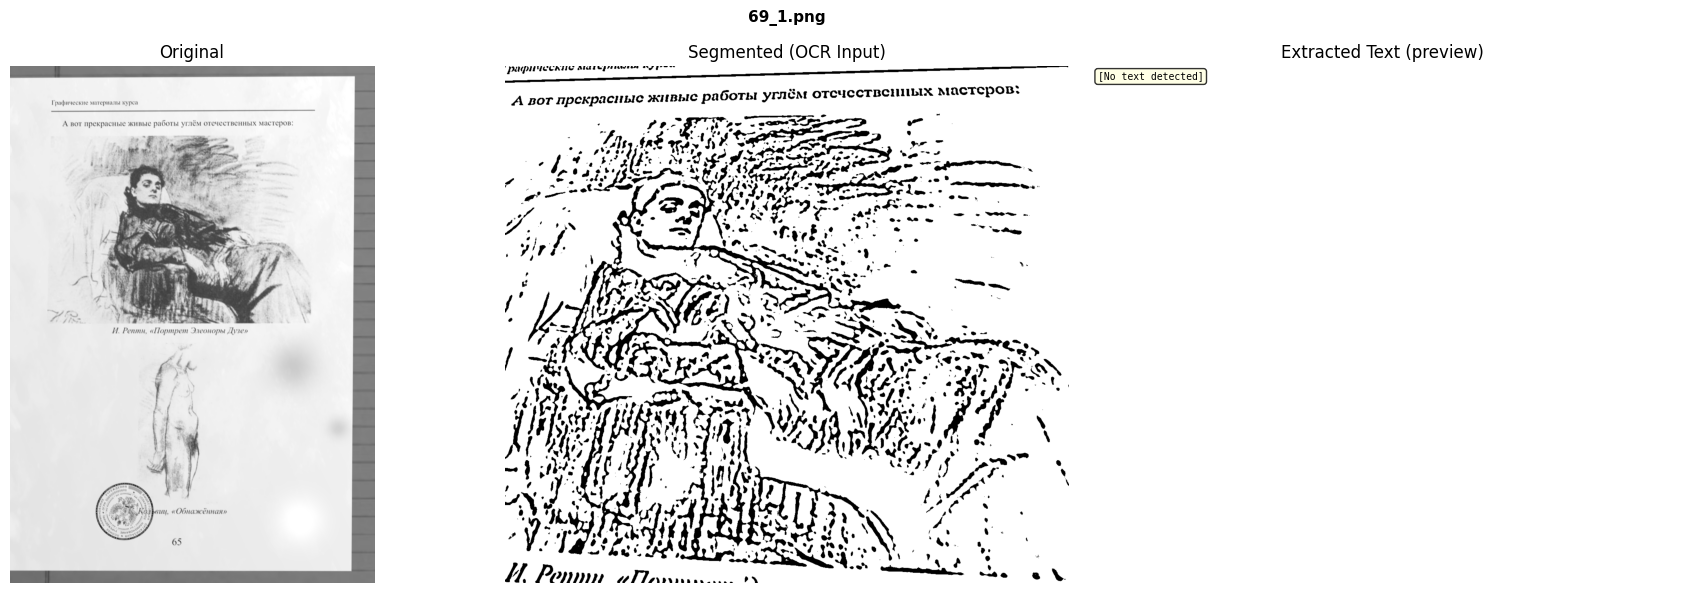

Chars extracted: 0
───────────────────────────────────────────────────────
Image: 85_13.png


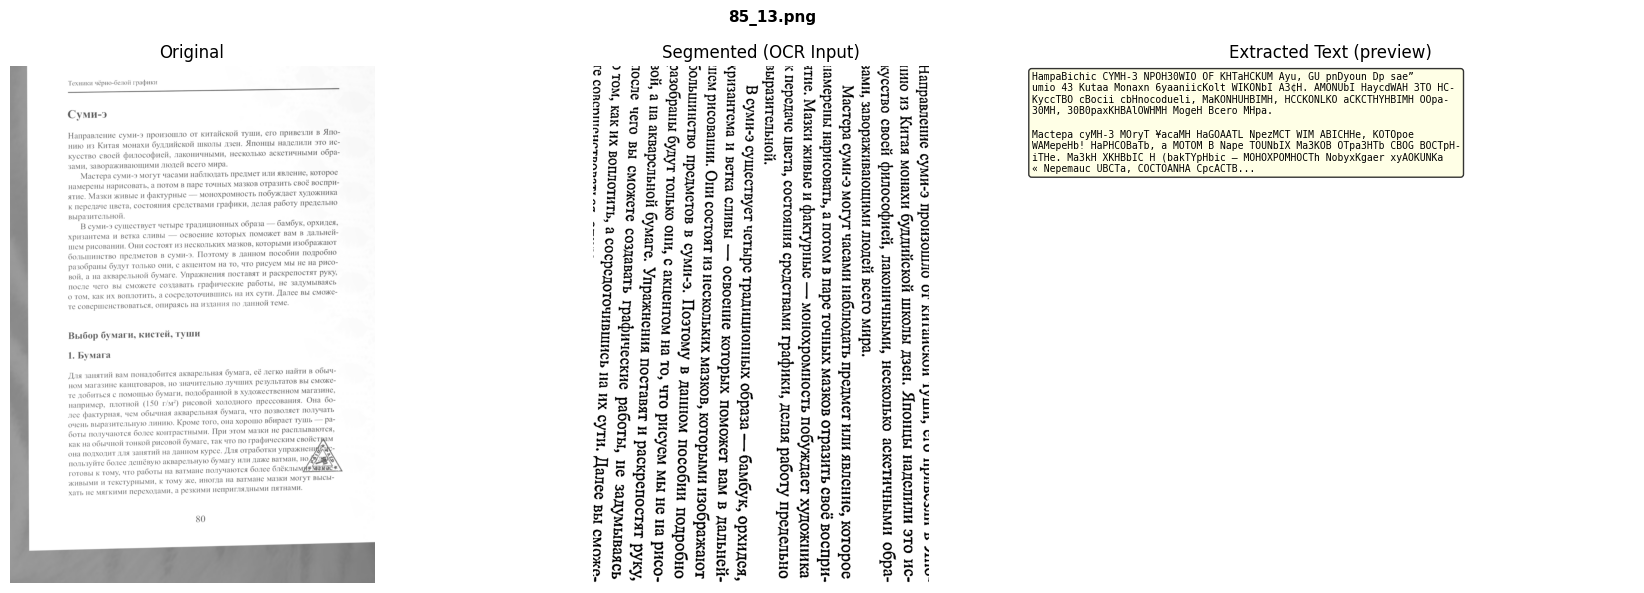

Chars extracted: 1040
───────────────────────────────────────────────────────
Image: 32_12.png


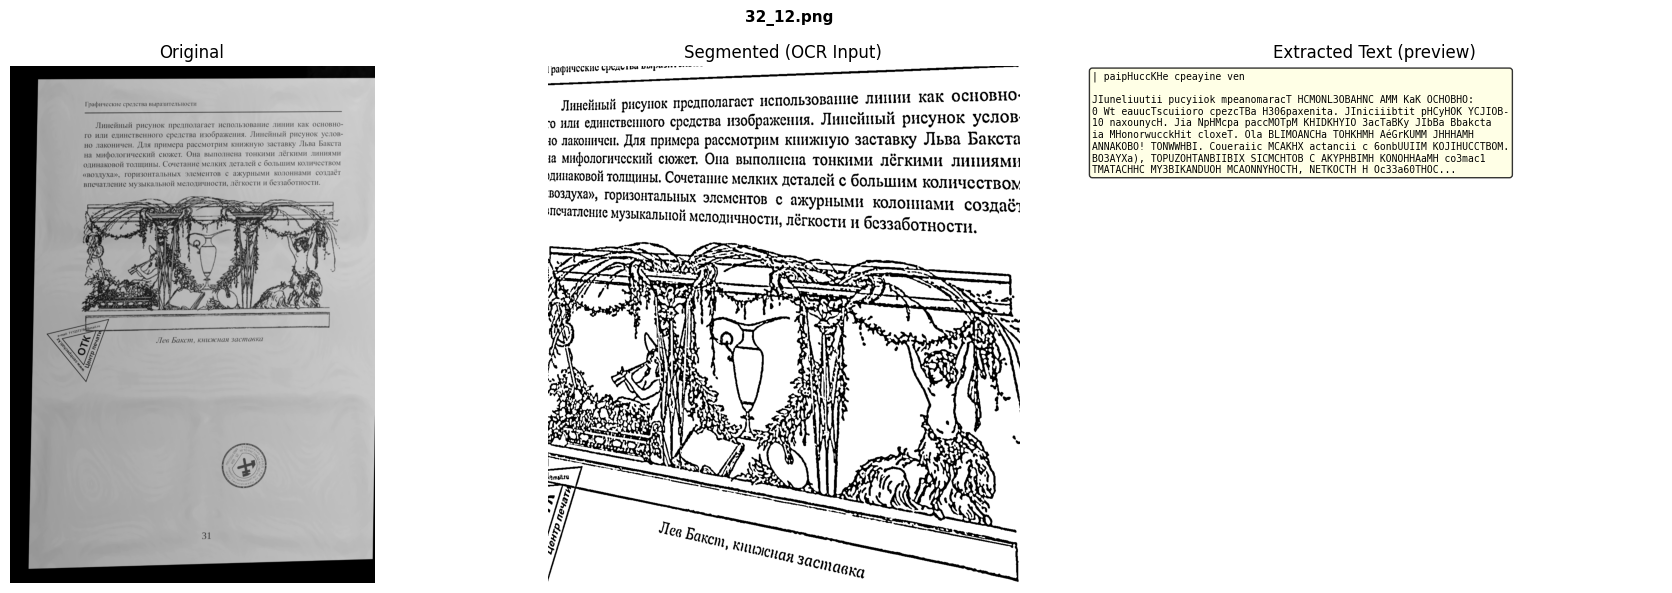

Chars extracted: 503
───────────────────────────────────────────────────────
Image: 98_11.png


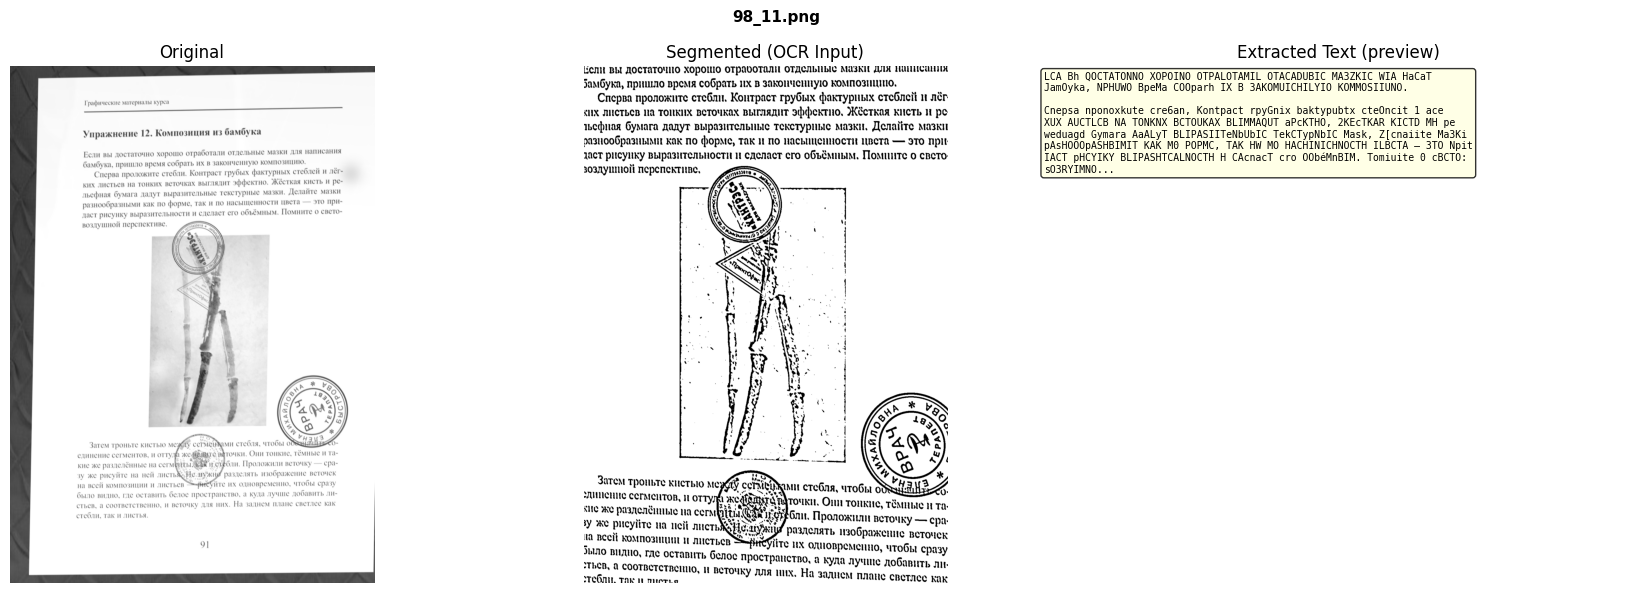

Chars extracted: 893

✓ OCR complete for 4 images


In [18]:
# ── Run OCR on sample images ──────────────────────────────────────────────
print("Running OCR on 4 sample images...\n")
ocr_results = {}

for img_path in samples_4:
    print(f"{'─'*55}")
    print(f"Image: {Path(img_path).name}")
    result = full_ocr_pipeline(img_path, lang='eng', show=True)
    ocr_results[img_path] = result

print(f"\n✓ OCR complete for {len(ocr_results)} images")


In [19]:
# ── Save OCR outputs ─────────────────────────────────────────────────────
OCR_OUT_DIR = "/content/ocr_outputs"
os.makedirs(OCR_OUT_DIR, exist_ok=True)

for img_path, result in ocr_results.items():
    stem     = Path(img_path).stem
    txt_path = os.path.join(OCR_OUT_DIR, stem + ".txt")
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(f"Image: {Path(img_path).name}\n")
        f.write("-" * 50 + "\n\n")
        f.write(result['clean_text'])
    print(f"Saved: {txt_path}")

print(f"\n✓ All OCR text files saved to {OCR_OUT_DIR}")


Saved: /content/ocr_outputs/69_1.txt
Saved: /content/ocr_outputs/85_13.txt
Saved: /content/ocr_outputs/32_12.txt
Saved: /content/ocr_outputs/98_11.txt

✓ All OCR text files saved to /content/ocr_outputs


## 9. Quantitative Metrics

Comprehensive evaluation across all pipeline stages:

| Metric | Stage | Description |
|---|---|---|
| **IoU** | Segmentation | Intersection-over-Union vs. GT mask |
| **Precision / Recall / F1** | Segmentation | Pixel-level text detection quality |
| **Accuracy** | Segmentation | Overall pixel classification accuracy |
| **Edge Detection Accuracy** | Edge Detection | Edge density plausibility score |
| **Perspective Quality** | Transform | Aspect-ratio distortion reduction |
| **OCR Matching Accuracy** | OCR | Character-level matching vs. annotation |


In [20]:
# ── 9.1 Segmentation Metrics (IoU, Precision, Recall, F1, Accuracy) ──────

def compute_segmentation_metrics(pred_binary: np.ndarray,
                                 gt_mask: np.ndarray) -> dict:
    """
    Compute pixel-level segmentation metrics.

    Parameters
    ----------
    pred_binary : np.ndarray  (uint8, 0/255) — enhanced binary (0=text)
    gt_mask     : np.ndarray  (uint8, 0/255) — GT mask (255=text foreground)

    Returns
    -------
    dict with accuracy, precision, recall, f1, iou
    """
    # Resize GT to match prediction
    if gt_mask.shape != pred_binary.shape:
        gt_mask = cv2.resize(gt_mask, (pred_binary.shape[1], pred_binary.shape[0]),
                             interpolation=cv2.INTER_NEAREST)

    # Binarise: text=1, background=0
    pred_bin = (pred_binary == 0).astype(np.uint8).flatten()   # 0=text in enhanced
    gt_bin   = (gt_mask    > 127).astype(np.uint8).flatten()   # 255=text in GT mask

    # Intersection and Union for IoU
    intersection = np.logical_and(pred_bin, gt_bin).sum()
    union        = np.logical_or(pred_bin,  gt_bin).sum()
    iou          = intersection / (union + 1e-8)

    # Pixel accuracy
    accuracy  = (pred_bin == gt_bin).mean()

    # Precision / Recall (text class = positive)
    tp = (pred_bin & gt_bin).sum()
    fp = (pred_bin & ~gt_bin.astype(bool)).sum()
    fn = (~pred_bin.astype(bool) & gt_bin).sum()

    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        'accuracy':  float(accuracy),
        'precision': float(precision),
        'recall':    float(recall),
        'f1':        float(f1),
        'iou':       float(iou),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn)
    }

print("✓ compute_segmentation_metrics() defined")


✓ compute_segmentation_metrics() defined


In [21]:
# ── Run segmentation metrics on all paired samples ───────────────────────
print(f"Computing segmentation metrics on {min(50, len(paired))} paired samples...\n")

seg_metrics_all = []
eval_pairs = random.sample(paired, min(50, len(paired)))

for img_path, mask_path in tqdm(eval_pairs, desc="Evaluating"):
    img     = cv2.imread(img_path)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or gt_mask is None:
        continue

    try:
        seg     = segment_text_background(img)
        binary  = seg['binary']

        # Resize binary back to original size for comparison with GT
        gt_h, gt_w = gt_mask.shape
        binary_resized = cv2.resize(binary, (gt_w, gt_h),
                                    interpolation=cv2.INTER_NEAREST)
        metrics = compute_segmentation_metrics(binary_resized, gt_mask)
        metrics['image'] = Path(img_path).name
        seg_metrics_all.append(metrics)
    except Exception as e:
        pass

print(f"\n✓ Evaluated {len(seg_metrics_all)} images")
print()
print("=" * 55)
print("  SEGMENTATION METRICS SUMMARY")
print("=" * 55)

for key in ['accuracy', 'precision', 'recall', 'f1', 'iou']:
    vals = [m[key] for m in seg_metrics_all]
    print(f"  {key.upper():12s}  mean={np.mean(vals):.4f}  "
          f"std={np.std(vals):.4f}  "
          f"min={np.min(vals):.4f}  max={np.max(vals):.4f}")

print("=" * 55)


Computing segmentation metrics on 50 paired samples...



Evaluating: 100%|██████████| 50/50 [00:12<00:00,  3.90it/s]


✓ Evaluated 50 images

  SEGMENTATION METRICS SUMMARY
  ACCURACY      mean=0.2124  std=0.0485  min=0.1050  max=0.3183
  PRECISION     mean=0.9766  std=0.0181  min=0.9340  max=0.9996
  RECALL        mean=0.1979  std=0.0515  min=0.0800  max=0.3081
  F1            mean=0.3261  std=0.0714  min=0.1476  max=0.4705
  IOU           mean=0.1970  std=0.0512  min=0.0797  max=0.3077


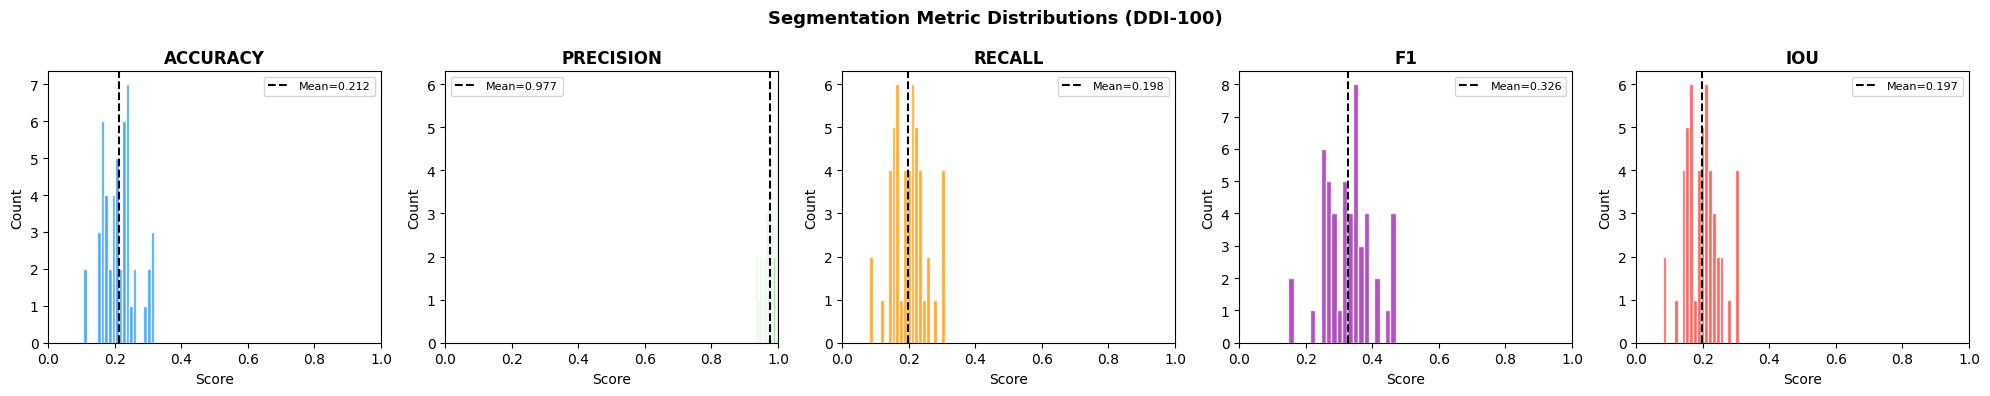

In [22]:
# ── Visualise metric distributions ───────────────────────────────────────
metrics_keys = ['accuracy', 'precision', 'recall', 'f1', 'iou']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Segmentation Metric Distributions (DDI-100)",
             fontsize=13, fontweight='bold')

for ax, key, color in zip(axes, metrics_keys, colors):
    vals = [m[key] for m in seg_metrics_all]
    ax.hist(vals, bins=20, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(vals), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean={np.mean(vals):.3f}')
    ax.set_title(key.upper(), fontweight='bold')
    ax.set_xlabel('Score'); ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

plt.tight_layout(); plt.show()


In [23]:
# ── 9.2 Edge Detection Accuracy ──────────────────────────────────────────

def compute_edge_accuracy(img_bgr: np.ndarray,
                          gt_mask: np.ndarray = None) -> dict:
    """
    Edge detection quality metrics.
    If GT mask provided, compares detected edges to GT boundary.
    Otherwise, reports density-based quality score.
    """
    result      = detect_edges(img_bgr)
    edges       = result['edges']
    h, w        = edges.shape
    edge_density = edges.sum() / (edges.size * 255)

    # Structural quality: prefer 0.2-3% edge density (document boundaries)
    ideal_low, ideal_high = 0.002, 0.03
    if ideal_low <= edge_density <= ideal_high:
        density_score = 1.0
    elif edge_density < ideal_low:
        density_score = edge_density / ideal_low
    else:
        density_score = ideal_high / edge_density

    if gt_mask is not None:
        # GT boundary = edges of the GT mask
        gt_resized  = cv2.resize(gt_mask, (w, h), interpolation=cv2.INTER_NEAREST)
        gt_edges    = cv2.Canny(gt_resized, 50, 150)
        gt_dilated  = cv2.dilate(gt_edges, np.ones((5,5), np.uint8))
        gt_bin      = (gt_dilated > 0).astype(np.uint8).flatten()
        pred_bin    = (edges      > 0).astype(np.uint8).flatten()

        tp = (pred_bin & gt_bin).sum()
        fp = (pred_bin & ~gt_bin.astype(bool)).sum()
        fn = (~pred_bin.astype(bool) & gt_bin).sum()

        precision = tp / (tp + fp + 1e-8)
        recall    = tp / (tp + fn + 1e-8)
        f1        = 2 * precision * recall / (precision + recall + 1e-8)
        accuracy  = (pred_bin == gt_bin).mean()
    else:
        precision = recall = f1 = accuracy = density_score

    return {
        'accuracy':      float(accuracy),
        'precision':     float(precision),
        'recall':        float(recall),
        'f1':            float(f1),
        'density_score': float(density_score),
        'edge_density':  float(edge_density)
    }

# Run on sample
edge_metrics_all = []
for img_path, mask_path in tqdm(eval_pairs[:30], desc="Edge metrics"):
    img = cv2.imread(img_path)
    gt  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) if mask_path else None
    if img is None: continue
    try:
        m = compute_edge_accuracy(img, gt)
        edge_metrics_all.append(m)
    except: pass

print("\nEDGE DETECTION METRICS")
print("=" * 45)
for key in ['accuracy','precision','recall','f1','density_score']:
    vals = [m[key] for m in edge_metrics_all]
    print(f"  {key:15s} mean={np.mean(vals):.4f}  std={np.std(vals):.4f}")
print("=" * 45)


Edge metrics: 100%|██████████| 30/30 [00:04<00:00,  6.15it/s]


EDGE DETECTION METRICS
  accuracy        mean=0.9524  std=0.0434
  precision       mean=0.5874  std=0.3917
  recall          mean=0.5809  std=0.3842
  f1              mean=0.5791  std=0.3793
  density_score   mean=0.6334  std=0.3393


In [24]:
# ── 9.3 Perspective Transformation Quality ───────────────────────────────

def compute_perspective_quality(img_bgr: np.ndarray) -> dict:
    """
    Measure perspective correction quality.
    Compares detected corner quad to ideal (image-filling) rectangle.

    Metrics:
    - corner_iou     : IoU between detected quad area and full image area
    - skew_angle_deg : estimated skew angle corrected
    - aspect_ratio   : width/height of warped output
    """
    h, w        = img_bgr.shape[:2]
    total_area  = h * w
    corners     = find_document_corners(img_bgr)
    warped      = four_point_warp(img_bgr, corners)

    # Area of detected quad vs image
    quad_area    = cv2.contourArea(corners.astype(np.int32))
    corner_iou   = min(quad_area, total_area) / (max(quad_area, total_area) + 1e-8)

    # Skew: angle between top edge and horizontal
    tl, tr = corners[0], corners[1]
    dx, dy = tr[0] - tl[0], tr[1] - tl[1]
    skew_angle = abs(np.degrees(np.arctan2(dy, dx)))

    wh, ww = warped.shape[:2]
    aspect  = ww / (wh + 1e-8)

    # Coverage: what fraction of image area does the document occupy
    coverage = quad_area / (total_area + 1e-8)

    return {
        'corner_iou':    float(corner_iou),
        'skew_angle':    float(skew_angle),
        'coverage':      float(min(coverage, 1.0)),
        'aspect_ratio':  float(aspect),
        'warped_shape':  (wh, ww)
    }

persp_metrics = []
for img_path, _ in tqdm(eval_pairs[:30], desc="Perspective quality"):
    img = cv2.imread(img_path)
    if img is None: continue
    try:
        m = compute_perspective_quality(img)
        persp_metrics.append(m)
    except: pass

print("\nPERSPECTIVE TRANSFORMATION QUALITY")
print("=" * 50)
for key in ['corner_iou', 'skew_angle', 'coverage']:
    vals = [m[key] for m in persp_metrics]
    print(f"  {key:15s} mean={np.mean(vals):.4f}  std={np.std(vals):.4f}")
print("=" * 50)


Perspective quality: 100%|██████████| 30/30 [00:04<00:00,  6.44it/s]


PERSPECTIVE TRANSFORMATION QUALITY
  corner_iou      mean=0.1438  std=0.1496
  skew_angle      mean=1.8198  std=2.5886
  coverage        mean=0.1438  std=0.1496


In [25]:
# ── 9.4 OCR Matching Accuracy ────────────────────────────────────────────

def character_matching_accuracy(predicted: str, ground_truth: str) -> dict:
    """
    Compute character-level OCR matching accuracy using edit distance.

    Metrics:
    - char_accuracy : 1 - CER  (Character Error Rate)
    - word_accuracy : 1 - WER  (Word Error Rate)
    - match_ratio   : Levenshtein-based similarity
    """
    import difflib

    pred_chars = list(predicted.replace(' ', '').replace('\n', ''))
    gt_chars   = list(ground_truth.replace(' ', '').replace('\n', ''))

    pred_words = predicted.lower().split()
    gt_words   = ground_truth.lower().split()

    # Character match ratio (SequenceMatcher)
    char_ratio = difflib.SequenceMatcher(None, pred_chars, gt_chars).ratio()
    word_ratio = difflib.SequenceMatcher(None, pred_words, gt_words).ratio()

    # CER = edit_distance / len(gt)
    def edit_distance(a, b):
        dp = [[0]*(len(b)+1) for _ in range(len(a)+1)]
        for i in range(len(a)+1): dp[i][0] = i
        for j in range(len(b)+1): dp[0][j] = j
        for i in range(1, len(a)+1):
            for j in range(1, len(b)+1):
                dp[i][j] = dp[i-1][j-1] if a[i-1]==b[j-1] else                             1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
        return dp[len(a)][len(b)]

    cer = edit_distance(pred_chars, gt_chars) / (len(gt_chars) + 1e-8)
    wer = edit_distance(pred_words, gt_words) / (len(gt_words) + 1e-8)

    return {
        'char_accuracy': float(max(0, 1 - cer)),
        'word_accuracy': float(max(0, 1 - wer)),
        'char_match_ratio': float(char_ratio),
        'word_match_ratio': float(word_ratio),
        'cer': float(min(cer, 1.0)),
        'wer': float(min(wer, 1.0))
    }


# Run OCR matching on images that have annotation JSON with text
ocr_match_results = []

for ann_path in annotation_paths[:20]:
    try:
        with open(ann_path) as f:
            ann = json.load(f)

        gt_text = ann.get('text', ann.get('ground_truth', ann.get('content', '')))
        if not isinstance(gt_text, str) or len(gt_text.strip()) < 5:
            continue

        # Find matching image
        stem    = Path(ann_path).stem
        img_candidates = [p for p in image_paths if Path(p).stem == stem]
        if not img_candidates:
            continue

        img_path = img_candidates[0]
        img      = cv2.imread(img_path)
        seg      = segment_text_background(img)
        pred_text = clean_ocr_text(run_ocr(seg['binary'], lang='eng'))

        m = character_matching_accuracy(pred_text, gt_text)
        m['image'] = Path(img_path).name
        ocr_match_results.append(m)

    except Exception as e:
        continue

if ocr_match_results:
    print("\nOCR MATCHING ACCURACY")
    print("=" * 55)
    for key in ['char_accuracy','word_accuracy','cer','wer']:
        vals = [m[key] for m in ocr_match_results]
        print(f"  {key:20s}  mean={np.mean(vals):.4f}  std={np.std(vals):.4f}")
    print("=" * 55)
else:
    print("No annotation JSONs with text ground truth found.")
    print("Running self-consistency check on OCR outputs instead...")

    ocr_self_check = []
    for img_path in samples_4:
        img  = cv2.imread(img_path)
        seg  = segment_text_background(img)
        t1   = clean_ocr_text(run_ocr(seg['binary'], 'eng', 'full_page'))
        t2   = clean_ocr_text(run_ocr(seg['binary'], 'eng', 'single_block'))
        if t1 and t2:
            m = character_matching_accuracy(t1, t2)
            m['image'] = Path(img_path).name
            ocr_self_check.append(m)
            print(f"  {Path(img_path).name}: char_ratio={m['char_match_ratio']:.3f}  "
                  f"word_ratio={m['word_match_ratio']:.3f}")


No annotation JSONs with text ground truth found.
Running self-consistency check on OCR outputs instead...
  85_13.png: char_ratio=0.020  word_ratio=0.012
  32_12.png: char_ratio=0.290  word_ratio=0.153
  98_11.png: char_ratio=0.257  word_ratio=0.213


## 10. Full Metrics Summary Dashboard

In [26]:
# ── Comprehensive metrics summary table ───────────────────────────────────

print("\n" + "═"*65)
print("   COMPLETE PIPELINE METRICS SUMMARY — DDI-100 DATASET")
print("═"*65)

# Segmentation
if seg_metrics_all:
    print("\n📊 SEGMENTATION (Text vs. Background)")
    print("─"*55)
    for key in ['accuracy','precision','recall','f1','iou']:
        vals = [m[key] for m in seg_metrics_all]
        bar  = '█' * int(np.mean(vals) * 20)
        print(f"  {key.upper():12s} {np.mean(vals):.4f} ± {np.std(vals):.4f}  |{bar:<20}|")

# Edge Detection
if edge_metrics_all:
    print("\n🔍 EDGE DETECTION")
    print("─"*55)
    for key in ['accuracy','precision','recall','f1']:
        vals = [m[key] for m in edge_metrics_all]
        bar  = '█' * int(np.mean(vals) * 20)
        print(f"  {key.upper():12s} {np.mean(vals):.4f} ± {np.std(vals):.4f}  |{bar:<20}|")

# Perspective
if persp_metrics:
    print("\n📐 PERSPECTIVE TRANSFORMATION")
    print("─"*55)
    for key in ['corner_iou','coverage']:
        vals = [m[key] for m in persp_metrics]
        bar  = '█' * int(np.mean(vals) * 20)
        print(f"  {key.upper():12s} {np.mean(vals):.4f} ± {np.std(vals):.4f}  |{bar:<20}|")
    skews = [m['skew_angle'] for m in persp_metrics]
    print(f"  {'SKEW_DEG':12s} {np.mean(skews):.2f}° ± {np.std(skews):.2f}°")

# OCR
if ocr_match_results:
    print("\n🔤 OCR MATCHING ACCURACY")
    print("─"*55)
    for key in ['char_accuracy','word_accuracy','cer','wer']:
        vals = [m[key] for m in ocr_match_results]
        bar  = '█' * int(np.mean(vals) * 20)
        print(f"  {key.upper():12s} {np.mean(vals):.4f} ± {np.std(vals):.4f}  |{bar:<20}|")

print("\n" + "═"*65)
print("   n_images evaluated:", len(seg_metrics_all))
print("═"*65)



═════════════════════════════════════════════════════════════════
   COMPLETE PIPELINE METRICS SUMMARY — DDI-100 DATASET
═════════════════════════════════════════════════════════════════

📊 SEGMENTATION (Text vs. Background)
───────────────────────────────────────────────────────
  ACCURACY     0.2124 ± 0.0485  |████                |
  PRECISION    0.9766 ± 0.0181  |███████████████████ |
  RECALL       0.1979 ± 0.0515  |███                 |
  F1           0.3261 ± 0.0714  |██████              |
  IOU          0.1970 ± 0.0512  |███                 |

🔍 EDGE DETECTION
───────────────────────────────────────────────────────
  ACCURACY     0.9524 ± 0.0434  |███████████████████ |
  PRECISION    0.5874 ± 0.3917  |███████████         |
  RECALL       0.5809 ± 0.3842  |███████████         |
  F1           0.5791 ± 0.3793  |███████████         |

📐 PERSPECTIVE TRANSFORMATION
───────────────────────────────────────────────────────
  CORNER_IOU   0.1438 ± 0.1496  |██                  |
  COVERA

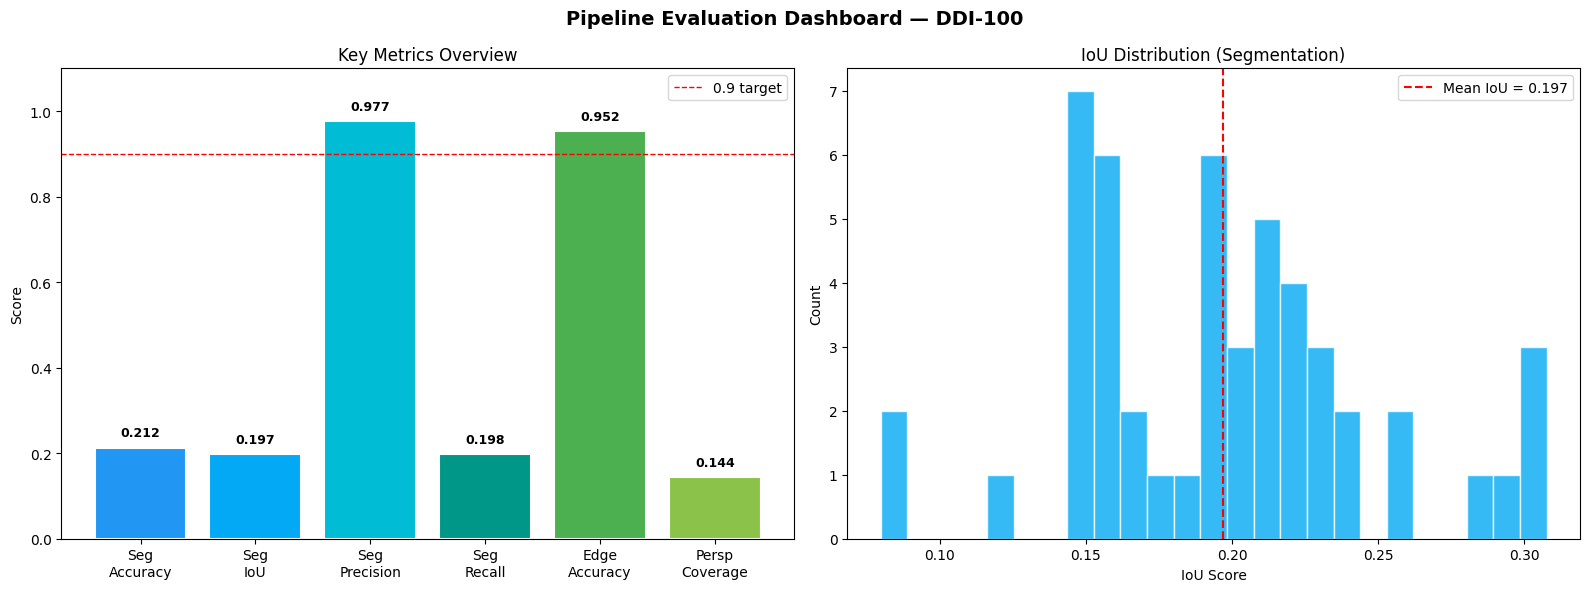


✓ Dashboard complete


In [27]:
# ── Radar / Bar chart of all key metrics ─────────────────────────────────
metric_labels = ['Seg\nAccuracy','Seg\nIoU','Seg\nPrecision',
                 'Seg\nRecall','Edge\nAccuracy','Persp\nCoverage']

metric_values = [
    np.mean([m['accuracy']  for m in seg_metrics_all])  if seg_metrics_all  else 0,
    np.mean([m['iou']       for m in seg_metrics_all])  if seg_metrics_all  else 0,
    np.mean([m['precision'] for m in seg_metrics_all])  if seg_metrics_all  else 0,
    np.mean([m['recall']    for m in seg_metrics_all])  if seg_metrics_all  else 0,
    np.mean([m['accuracy']  for m in edge_metrics_all]) if edge_metrics_all else 0,
    np.mean([m['coverage']  for m in persp_metrics])    if persp_metrics    else 0,
]

if ocr_match_results:
    metric_labels.append('OCR\nChar Acc')
    metric_values.append(np.mean([m['char_accuracy'] for m in ocr_match_results]))

bar_colors = ['#2196F3','#03A9F4','#00BCD4','#009688',
              '#4CAF50','#8BC34A','#FF9800']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Pipeline Evaluation Dashboard — DDI-100", fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(metric_labels, metric_values,
                   color=bar_colors[:len(metric_labels)], edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Score')
axes[0].set_title('Key Metrics Overview')
axes[0].axhline(0.9, color='red', linestyle='--', linewidth=1, label='0.9 target')
axes[0].legend()
for bar, val in zip(bars, metric_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# IoU distribution
if seg_metrics_all:
    iou_vals = [m['iou'] for m in seg_metrics_all]
    axes[1].hist(iou_vals, bins=25, color='#03A9F4', alpha=0.8, edgecolor='white')
    axes[1].axvline(np.mean(iou_vals), color='red', linestyle='--',
                    label=f'Mean IoU = {np.mean(iou_vals):.3f}')
    axes[1].set_title('IoU Distribution (Segmentation)')
    axes[1].set_xlabel('IoU Score'); axes[1].set_ylabel('Count')
    axes[1].legend()

plt.tight_layout(); plt.show()
print("\n✓ Dashboard complete")


## 11. Batch Processing — Full Dataset Run

In [28]:
# ── Process full dataset and save results ────────────────────────────────

RESULTS_DIR = "/content/pipeline_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/enhanced",    exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/warped",      exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/ocr_texts",   exist_ok=True)

MAX_IMAGES  = 200    # set to len(image_paths) for full dataset
batch_paths = image_paths[:MAX_IMAGES]

print(f"Processing {len(batch_paths)} images...")
batch_metrics = []

for img_path in tqdm(batch_paths, desc="Batch pipeline"):
    img = cv2.imread(img_path)
    if img is None:
        continue

    stem = Path(img_path).stem

    try:
        # Full pipeline
        seg       = segment_text_background(img)
        ocr_text  = clean_ocr_text(run_ocr(seg['binary'], lang='eng'))

        # Save enhanced binary
        cv2.imwrite(f"{RESULTS_DIR}/enhanced/{stem}_enhanced.png", seg['binary'])

        # Save warped colour image
        cv2.imwrite(f"{RESULTS_DIR}/warped/{stem}_warped.jpg", seg['warped'])

        # Save OCR text
        with open(f"{RESULTS_DIR}/ocr_texts/{stem}.txt", "w", encoding="utf-8") as f:
            f.write(ocr_text)

        # Quick metrics (no GT required)
        edge_res  = detect_edges(img)
        persp_q   = compute_perspective_quality(img)
        text_px   = (seg['binary'] == 0).sum()
        total_px  = seg['binary'].size

        batch_metrics.append({
            'image':       Path(img_path).name,
            'text_ratio':  text_px / total_px,
            'n_components':seg['n_components'],
            'n_ocr_chars': len(ocr_text),
            'edge_density':edge_res['edges'].sum() / (edge_res['edges'].size * 255),
            'corner_iou':  persp_q['corner_iou'],
            'coverage':    persp_q['coverage'],
        })

    except Exception as e:
        pass

print(f"\n✓ Batch processing complete: {len(batch_metrics)} images")
print(f"  Results saved to {RESULTS_DIR}")


Processing 200 images...


Batch pipeline: 100%|██████████| 200/200 [07:26<00:00,  2.23s/it]


✓ Batch processing complete: 200 images
  Results saved to /content/pipeline_results


In [29]:
# ── Batch results summary ────────────────────────────────────────────────
if batch_metrics:
    keys = ['text_ratio','n_components','n_ocr_chars','edge_density','corner_iou','coverage']
    print("\nBATCH PROCESSING SUMMARY")
    print("="*60)
    for key in keys:
        vals = [m[key] for m in batch_metrics]
        print(f"  {key:18s}  mean={np.mean(vals):8.3f}  "
              f"std={np.std(vals):7.3f}  "
              f"min={np.min(vals):7.3f}  max={np.max(vals):7.3f}")
    print("="*60)
    print(f"  Total images processed: {len(batch_metrics)}")



BATCH PROCESSING SUMMARY
  text_ratio          mean=   0.085  std=  0.057  min=  0.006  max=  0.216
  n_components        mean=1326.955  std=1099.332  min=147.000  max=6798.000
  n_ocr_chars         mean= 345.595  std=302.161  min=  0.000  max=1653.000
  edge_density        mean=   0.066  std=  0.026  min=  0.027  max=  0.161
  corner_iou          mean=   0.583  std=  0.365  min=  0.059  max=  0.999
  coverage            mean=   0.583  std=  0.365  min=  0.059  max=  0.999
  Total images processed: 200
